In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

In [ ]:
from info_patterns.parameters import (SPHERE_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_STEP_NM, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, FAST_FARFIELD_PARAMS, DEFAULT_DYADS_PARAMS, 
                                      DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_FILLING_FACTOR, DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS, DEFAULT_OPTICAL_POWER_W, 
                                      DEFAULT_FREE_SPACE_IMPEDANCE_OHM)
from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material, nanoparticle_mass)
from info_patterns.light_matter_interaction_simulation import (w0_from_filling_factor, hermite_gauss00_power_amplitude_factor, incident_field, field_propagation, 
                                                               scattered_farfield_from_simulation)
from info_patterns.measurement_tools import (force_vs_displacement, recoil_force_noise_psd, trap_frequency, heating_rate)
from info_patterns.plots import (set_plot_style)
set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "recoil_heating_hermite_gauss00_results"

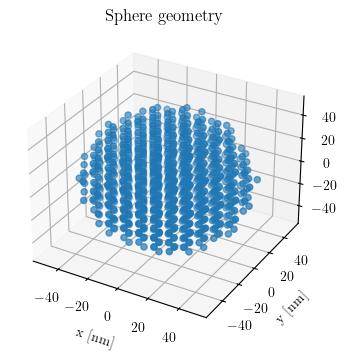

Geometry shape: (853, 3)
Geometry center: [ 0.0000000e+00  1.3706972e-06 -5.1813695e-05]
Material: <pyGDM2.materials.sio2 object at 0x12ea930d0>
Mass: 1.326957e-18 kg


In [3]:
step_nm = DEFAULT_STEP_NM
geometry = nanoparticle_geometry(**SPHERE_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
mass = nanoparticle_mass(geometry=geometry, particle_type=SPHERE_GEOMETRY_PARAMS["particle_type"], step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material_name=DEFAULT_MATERIAL_NAME, 
                         mesh=SPHERE_GEOMETRY_PARAMS["mesh"], method="discrete")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Sphere geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)
print(f"Mass: {mass:.6e} kg")

In [ ]:
wavelength_nm = DEFAULT_WAVELENGTH_NM
farfield_params = FAST_FARFIELD_PARAMS

Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]

gamma = DEFAULT_FILLING_FACTOR
optical_power_W = DEFAULT_OPTICAL_POWER_W
impedance_ohm = DEFAULT_FREE_SPACE_IMPEDANCE_OHM
hermite_params = DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS.copy()

hermite_params["w0"] = w0_from_filling_factor(gamma=gamma, NA=hermite_params["NA"], f_mm=hermite_params["f"])
hermite_amplitude = hermite_gauss00_power_amplitude_factor(optical_power_W=optical_power_W, w0_mm=hermite_params["w0"], impedance_ohm=impedance_ohm)

# HermiteGauss00 requires exactly one of theta or polarization_state.
# Use polarization_state to include the physical amplitude.
hermite_params["theta"] = None
hermite_params["polarization_state"] = (hermite_amplitude, 0.0, 0.0, 0.0)

print("Incident field: HermiteGauss00")
print("gamma =", gamma)
print("NA =", hermite_params["NA"])
print("f =", hermite_params["f"], "mm")
print("w0 =", hermite_params["w0"], "mm")
print("optical power =", optical_power_W, "W")
print("amplitude factor =", hermite_amplitude)
print("normalize =", hermite_params["normalize"])
print("theta =", hermite_params["theta"])
print("polarization_state =", hermite_params["polarization_state"])

efield = incident_field(**hermite_params)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

Incident field: HermiteGauss00
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm
optical power = 0.001 W
amplitude factor = 10.000117794776598
normalize = False
theta = None
polarization_state = (10.000117794776598, 0.0, 0.0, 0.0)


In [9]:
E_scat = scattered_farfield_from_simulation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, Nteta=Nteta, Nphi=Nphi, 
                                            field_index=field_index, r=r)

S_FF_x = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=0)
S_FF_y = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=1)
S_FF_z = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=2)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 40.0ms, inv.: 249.3ms, repropa.: 4205.4ms (1 field configs), tot: 4494.8ms


In [6]:
displacements = np.array([-200.0, 0.0, 200.0])
Force = force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=displacements, field_index=field_index)

Omega_x, k_x = trap_frequency(displacements, Force["X"][:, 0], mass)
Omega_y, k_y = trap_frequency(displacements, Force["Y"][:, 1], mass)
Omega_z, k_z = trap_frequency(displacements, Force["Z"][:, 2], mass)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 56.3ms, inv.: 248.1ms, repropa.: 5025.2ms (1 field configs), tot: 5329.8ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 38.6ms, inv.: 244.3ms, repropa.: 4342.9ms (1 field configs), tot: 4625.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 49.8ms, inv.: 269.1ms, repropa.: 5423.8ms (1 field configs), tot: 5743.0ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 41.1ms, inv.: 282.3ms, repropa.: 4686.0ms (1 field configs), tot: 5009.6ms
structure initialization - automatic mesh detection: hex

In [7]:
Gamma_x = heating_rate(S_FF_x, mass, Omega_x)
Gamma_y = heating_rate(S_FF_y, mass, Omega_y)
Gamma_z = heating_rate(S_FF_z, mass, Omega_z)

In [8]:
print("Mass")
print(f"m = {mass:.6e} kg")

print("\nTrap stiffness")
print(f"k_x = {k_x:.6e} N/m")
print(f"k_y = {k_y:.6e} N/m")
print(f"k_z = {k_z:.6e} N/m")

print("\nTrap frequencies")
print(f"Omega_x = {Omega_x:.6e} rad/s, f_x = {Omega_x / (2*np.pi):.6e} Hz")
print(f"Omega_y = {Omega_y:.6e} rad/s, f_y = {Omega_y / (2*np.pi):.6e} Hz")
print(f"Omega_z = {Omega_z:.6e} rad/s, f_z = {Omega_z / (2*np.pi):.6e} Hz")

print("\nRecoil force-noise PSD")
print(f"S_FF_x = {S_FF_x:.6e}")
print(f"S_FF_y = {S_FF_y:.6e}")
print(f"S_FF_z = {S_FF_z:.6e}")

print("\nRecoil heating rates")
print(f"Gamma_x = {Gamma_x:.6e} phonons/s")
print(f"Gamma_y = {Gamma_y:.6e} phonons/s")
print(f"Gamma_z = {Gamma_z:.6e} phonons/s")

Mass
m = 1.326957e-18 kg

Trap stiffness
k_x = 1.068106e-12 N/m
k_y = 2.163785e-12 N/m
k_z = 1.666403e-13 N/m

Trap frequencies
Omega_x = 8.971783e+02 rad/s, f_x = 1.427904e+02 Hz
Omega_y = 1.276964e+03 rad/s, f_y = 2.032351e+02 Hz
Omega_z = 3.543738e+02 rad/s, f_z = 5.640034e+01 Hz

Recoil force-noise PSD
S_FF_x = 7.890034e-49
S_FF_y = 1.547172e-48
S_FF_z = 1.540883e-48

Recoil heating rates
Gamma_x = 1.974318e+01 phonons/s
Gamma_y = 2.720050e+01 phonons/s
Gamma_z = 9.761690e+01 phonons/s
